<a href="https://colab.research.google.com/github/Nermen-Salama/PhD_practice/blob/toto2.0_313B/CWRU_Toto2_Capability_Probe_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Toto 2.0 Capability Probe — CWRU / Paderborn Bearing Prognostics

**Purpose**: establish what the Toto-2.0-313M time-series foundation model can and
cannot do for bearing PHM *before* investing in modifications.

**Tasks probed** (4-fault map: `{'BPFO':'OR','BPFI':'IR','BSF':'Ball','FTF':'Ball_cage'}` + Healthy):

| Task | Mechanism | Caveat |
|---|---|---|
| Fault classification | Frozen Toto embeddings → logistic regression | `Ball_cage` has **zero labeled data** in CWRU & Paderborn — placeholder class only |
| Severity (0/7/14/21 mil) | Same embeddings → classifier | CWRU only |
| RPM | **Raw-signal** embeddings → ridge regression | CWRU speed range is only 1730–1797 RPM (weak test) |
| RUL (proxy) | Toto probabilistic forecast of health-indicator trajectory → threshold crossing | CWRU is **not** run-to-failure; trajectory is a severity-ordered pseudo-degradation |

**Two input representations compared**:
1. **RAW** — 4096-sample vibration segment (out-of-distribution for Toto, trained on telemetry)
2. **ENV** — envelope order spectrum on a fixed 0–35× order grid (physics-informed: BPFO/BPFI/BSF/FTF sit at fixed positions regardless of speed)

**Leakage control**: train on loads 0–2, test on load 3 (unseen speed). RPM regression uses RAW only (ENV is built *with* shaft speed).

Runtime: Colab T4 GPU, ≈10–15 min end-to-end.


In [2]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
!pip install -q toto-models scipy requests tqdm matplotlib scikit-learn

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np, os, requests, glob, warnings, json, time
import torch
from tqdm import tqdm
from scipy.io import loadmat
from scipy.signal import hilbert, resample_poly
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, mean_absolute_error)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42); torch.manual_seed(42)

# ── Constants ──────────────────────────────────────────────────────
FS_CWRU = 12000
FS_PAD_RAW = 64000          # Paderborn native rate
FS_PAD  = 12000             # resampled to match CWRU (resample_poly 3/16)
CWRU_SEG_LEN = 4096
FAULT_KEYS   = ['Normal','IR','OR','Ball','Ball_cage']   # Ball_cage = placeholder (no data)
CWRU_SPEEDS_RPM = {0:1797, 1:1772, 2:1750, 3:1730}

# The 4-fault physical map requested:
FMAP = {'BPFO':'OR', 'BPFI':'IR', 'BSF':'Ball', 'FTF':'Ball_cage'}

def bearing_orders(n_balls, pitch_d, ball_d, contact_angle_deg=0):
    a = np.cos(np.radians(contact_angle_deg))
    d, D = ball_d, pitch_d
    return {
        'FTF':  0.5*(1-(d/D)*a),
        'BPFO': (n_balls/2)*(1-(d/D)*a),
        'BPFI': (n_balls/2)*(1+(d/D)*a),
        'BSF':  (D/(2*d))*(1-((d/D)*a)**2),
    }

CWRU_ORDERS = bearing_orders(9, 39.04, 7.94)     # SKF 6205 drive end
PAD_ORDERS  = bearing_orders(8, 28.5,  6.75)     # Paderborn 6203

RAW_SIGNALS_BY_SOURCE = {}

print("Setup complete.")
print(f"CWRU orders: {' | '.join(f'{k}={v:.3f}x' for k,v in CWRU_ORDERS.items())}")
print(f"PAD  orders: {' | '.join(f'{k}={v:.3f}x' for k,v in PAD_ORDERS.items())}")
print(f"Fault map:   {FMAP}")
print("NOTE: 'Ball_cage' (FTF) has no labeled recordings in CWRU or Paderborn.")

Setup complete.
CWRU orders: FTF=0.398x | BPFO=3.585x | BPFI=5.415x | BSF=2.357x
PAD  orders: FTF=0.382x | BPFO=3.053x | BPFI=4.947x | BSF=1.993x
Fault map:   {'BPFO': 'OR', 'BPFI': 'IR', 'BSF': 'Ball', 'FTF': 'Ball_cage'}
NOTE: 'Ball_cage' (FTF) has no labeled recordings in CWRU or Paderborn.


## 1. CWRU Data Loading
(verbatim loader from `CWRU_PLL_FHSS_DSSS_ZeroAI_06.ipynb`)

In [4]:
CWRU_FILES = {
    # Normal
    'Normal_0':{'key':'97','de':'X097_DE_time','fault':'Normal','sev':0,'load':0},
    'Normal_1':{'key':'98','de':'X098_DE_time','fault':'Normal','sev':0,'load':1},
    'Normal_2':{'key':'99','de':'X099_DE_time','fault':'Normal','sev':0,'load':2},
    'Normal_3':{'key':'100','de':'X100_DE_time','fault':'Normal','sev':0,'load':3},
    # IR
    'IR007_0':{'key':'105','de':'X105_DE_time','fault':'IR','sev':7,'load':0},
    'IR007_1':{'key':'106','de':'X106_DE_time','fault':'IR','sev':7,'load':1},
    'IR007_2':{'key':'107','de':'X107_DE_time','fault':'IR','sev':7,'load':2},
    'IR007_3':{'key':'108','de':'X108_DE_time','fault':'IR','sev':7,'load':3},
    'IR014_0':{'key':'169','de':'X169_DE_time','fault':'IR','sev':14,'load':0},
    'IR014_1':{'key':'170','de':'X170_DE_time','fault':'IR','sev':14,'load':1},
    'IR014_2':{'key':'171','de':'X171_DE_time','fault':'IR','sev':14,'load':2},
    'IR014_3':{'key':'172','de':'X172_DE_time','fault':'IR','sev':14,'load':3},
    'IR021_0':{'key':'209','de':'X209_DE_time','fault':'IR','sev':21,'load':0},
    'IR021_1':{'key':'210','de':'X210_DE_time','fault':'IR','sev':21,'load':1},
    'IR021_2':{'key':'211','de':'X211_DE_time','fault':'IR','sev':21,'load':2},
    'IR021_3':{'key':'212','de':'X212_DE_time','fault':'IR','sev':21,'load':3},
    # OR (6 o'clock)
    'OR007_0':{'key':'130','de':'X130_DE_time','fault':'OR','sev':7,'load':0},
    'OR007_1':{'key':'131','de':'X131_DE_time','fault':'OR','sev':7,'load':1},
    'OR007_2':{'key':'132','de':'X132_DE_time','fault':'OR','sev':7,'load':2},
    'OR007_3':{'key':'133','de':'X133_DE_time','fault':'OR','sev':7,'load':3},
    'OR014_0':{'key':'197','de':'X197_DE_time','fault':'OR','sev':14,'load':0},
    'OR014_1':{'key':'198','de':'X198_DE_time','fault':'OR','sev':14,'load':1},
    'OR014_2':{'key':'199','de':'X199_DE_time','fault':'OR','sev':14,'load':2},
    'OR014_3':{'key':'200','de':'X200_DE_time','fault':'OR','sev':14,'load':3},
    'OR021_0':{'key':'234','de':'X234_DE_time','fault':'OR','sev':21,'load':0},
    'OR021_1':{'key':'235','de':'X235_DE_time','fault':'OR','sev':21,'load':1},
    'OR021_2':{'key':'236','de':'X236_DE_time','fault':'OR','sev':21,'load':2},
    'OR021_3':{'key':'237','de':'X237_DE_time','fault':'OR','sev':21,'load':3},
    # Ball
    'B007_0':{'key':'118','de':'X118_DE_time','fault':'Ball','sev':7,'load':0},
    'B007_1':{'key':'119','de':'X119_DE_time','fault':'Ball','sev':7,'load':1},
    'B007_2':{'key':'120','de':'X120_DE_time','fault':'Ball','sev':7,'load':2},
    'B007_3':{'key':'121','de':'X121_DE_time','fault':'Ball','sev':7,'load':3},
    'B014_0':{'key':'185','de':'X185_DE_time','fault':'Ball','sev':14,'load':0},
    'B014_1':{'key':'186','de':'X186_DE_time','fault':'Ball','sev':14,'load':1},
    'B014_2':{'key':'187','de':'X187_DE_time','fault':'Ball','sev':14,'load':2},
    'B014_3':{'key':'188','de':'X188_DE_time','fault':'Ball','sev':14,'load':3},
    'B021_0':{'key':'222','de':'X222_DE_time','fault':'Ball','sev':21,'load':0},
    'B021_1':{'key':'223','de':'X223_DE_time','fault':'Ball','sev':21,'load':1},
    'B021_2':{'key':'224','de':'X224_DE_time','fault':'Ball','sev':21,'load':2},
    'B021_3':{'key':'225','de':'X225_DE_time','fault':'Ball','sev':21,'load':3},
}

SRCS = ["https://engineering.case.edu/sites/default/files/",
        "https://engineering.case.edu/bearingdatacenter/"]

def download_cwru(data_dir='./data/cwru'):
    os.makedirs(data_dir, exist_ok=True)
    for info in tqdm(CWRU_FILES.values(), desc='CWRU download'):
        p = os.path.join(data_dir, f"{info['key']}.mat")
        if os.path.exists(p) and os.path.getsize(p)>1000: continue
        for base in SRCS:
            try:
                r = requests.get(base+f"{info['key']}.mat", timeout=30)
                if r.status_code==200 and len(r.content)>1000:
                    open(p,'wb').write(r.content); break
            except: pass
    return data_dir

def load_cwru_segments(data_dir, seg_len=CWRU_SEG_LEN):
    segments = []
    for name, info in CWRU_FILES.items():
        p = os.path.join(data_dir, f"{info['key']}.mat")
        if not os.path.exists(p): continue
        try: mat = loadmat(p)
        except: continue
        de_key = info['de']
        if de_key not in mat:
            cands = [k for k in mat if 'DE_time' in k]
            de_key = cands[0] if cands else None
        if de_key is None: continue
        sig = mat[de_key].flatten()
        RAW_SIGNALS_BY_SOURCE[name] = sig
        rpm = CWRU_SPEEDS_RPM[info['load']]
        for i in range(len(sig)//seg_len):
            segments.append({
                'signal': sig[i*seg_len:(i+1)*seg_len],
                'fault': info['fault'], 'sev': info['sev'],
                'load': info['load'], 'source': name,
                'shaft_rpm_nominal': rpm, 'fs': FS_CWRU,
                'dataset': 'CWRU', 'seg_idx': i,
            })
    print(f"CWRU: {len(segments)} segments from {len(set(s['source'] for s in segments))} files")
    for f in FAULT_KEYS:
        n = sum(1 for s in segments if s['fault']==f)
        if n: print(f"  {f}: {n}")
    return segments

cwru_dir = download_cwru('./data/cwru')
cwru_segs = load_cwru_segments(cwru_dir)

CWRU download: 100%|██████████| 40/40 [00:02<00:00, 15.84it/s]

CWRU: 1458 segments from 40 files
  Normal: 413
  IR: 349
  OR: 348
  Ball: 348


## 2. Paderborn Data Loading
(verbatim loader from `CWRU_PLL_FHSS_DSSS_ZeroAI_06.ipynb`, plus one addition: signals are
**resampled 64 kHz → 12 kHz** (`resample_poly(sig, 3, 16)`) so RAW-representation embeddings
are comparable with CWRU.)

In [5]:
# ── Paderborn Dataset Loading ────────────────────────────────────────────────
# Google Drive folder ID: 1z3qNiTYtg4v_N_J7bKZSusAd2nI1vGd4
# Step 1 (once, in Colab):  from google.colab import drive; drive.mount('/content/drive')
# Step 2: add the shared folder as a shortcut in MyDrive; loader auto-detects.

PAD_FOLDER_ID = '1z3qNiTYtg4v_N_J7bKZSusAd2nI1vGd4'

PAD_DIR_CANDIDATES = [
        "/content/drive/MyDrive/Paderborn_Extracted",
    "/content/drive/MyDrive/Paderborn University's Vibration Bearing Dataset",
    "/content/drive/MyDrive/Paderborn",
    "/content/drive/MyDrive/PaderbornDataset",
    "/content/drive/MyDrive/Bearing Dataset"
]

PAD_MAP = {}
for b in ['K001','K002','K003','K004','K005','K006']: PAD_MAP[b]='Normal'
for b in ['KA01','KA03','KA05','KA06','KA07']: PAD_MAP[b]='OR'
for b in ['KI01','KI03','KI05','KI07','KI08']: PAD_MAP[b]='IR'
# NOTE: no cage-fault (FTF / 'Ball_cage') bearings exist in this map either.

def find_paderborn_dir():
    for candidate in PAD_DIR_CANDIDATES:
        if os.path.isdir(candidate):
            test_path = os.path.join(candidate, 'K001')
            alt_path  = os.path.join(candidate, 'Normal', 'K001')
            if os.path.isdir(test_path) or os.path.isdir(alt_path):
                print(f"Found Paderborn dataset at: {candidate}"); return candidate
            contents = os.listdir(candidate) if os.path.isdir(candidate) else []
            if any(b in contents for b in ['K001','KA01','KI01']):
                print(f"Found Paderborn dataset at: {candidate}"); return candidate
    mydrive = '/content/drive/MyDrive'
    if os.path.isdir(mydrive):
        for entry in os.listdir(mydrive):
            full = os.path.join(mydrive, entry)
            if os.path.isdir(full):
                contents = os.listdir(full)
                if any(b in contents for b in ['K001','KA01','KI01']):
                    print(f"Auto-detected Paderborn dataset at: {full}"); return full
                for sub in contents:
                    subfull = os.path.join(full, sub)
                    if os.path.isdir(subfull):
                        if any(b in os.listdir(subfull) for b in ['K001','KA01','KI01']):
                            print(f"Auto-detected Paderborn dataset at: {subfull}"); return subfull
    return None

def _parse_paderborn_mat(filepath):
    """mat[key]['Y'][0,0]['Data'][0,ch] — returns longest vibration channel."""
    try:
        mat = loadmat(filepath, squeeze_me=False)
        for key in mat:
            if key.startswith('_'): continue
            d = mat[key]
            if not (hasattr(d, 'dtype') and d.dtype.names): continue
            if 'Y' not in d.dtype.names: continue
            yd = d['Y'][0, 0]
            if 'Data' not in yd.dtype.names: continue
            data = yd['Data']
            best, best_len = None, 0
            n_ch = data.shape[1] if data.ndim >= 2 else 1
            for ch in range(n_ch):
                try:
                    sig = data[0, ch].flatten()
                    if sig.size < 10000: continue
                    if sig.max() - sig.min() > 0.01 and sig.size > best_len:
                        best = sig; best_len = sig.size
                except: continue
            if best is not None: return best
    except: pass
    return None

def load_paderborn_segments(data_dir, seg_len=CWRU_SEG_LEN):
    """Loads, resamples 64k->12k, segments at the SAME length as CWRU."""
    if not data_dir or not os.path.isdir(data_dir): return []
    segs = []; loaded_files = 0
    for bid, fault in PAD_MAP.items():
        bdir_candidates = [os.path.join(data_dir, bid),
                           os.path.join(data_dir, fault, bid),
                           os.path.join(data_dir, 'data', bid)]
        bdir = next((b for b in bdir_candidates if os.path.isdir(b)), None)
        if not bdir: continue
        mat_files = sorted(glob.glob(os.path.join(bdir, '*.mat')))
        if not mat_files:
            mat_files = sorted(glob.glob(os.path.join(bdir, '**', '*.mat'), recursive=True))
        for mf in mat_files[:2]:
            sig64 = _parse_paderborn_mat(mf)
            if sig64 is None: continue
            sig = resample_poly(sig64.astype(np.float64), 3, 16)   # 64k -> 12k exactly
            if len(sig) < seg_len: continue
            src = f"{bid}_{os.path.basename(mf)}"
            RAW_SIGNALS_BY_SOURCE[src] = sig
            loaded_files += 1
            for i in range(len(sig) // seg_len):
                segs.append({'signal': sig[i*seg_len:(i+1)*seg_len],
                    'fault': fault, 'sev': 0, 'load': 0, 'source': src,
                    'shaft_rpm_nominal': 1500.0, 'fs': FS_PAD,
                    'dataset': 'Paderborn', 'seg_idx': i})
    if loaded_files > 0:
        print(f"  Parsed {loaded_files} .mat files (resampled to {FS_PAD} Hz)")
    else:
        print("  WARNING: directory found but no .mat parsed. Check K001/KA01/KI01 subfolders.")
    return segs

PAD_DIR = find_paderborn_dir()
pad_segs = load_paderborn_segments(PAD_DIR)
PADERBORN_AVAILABLE = len(pad_segs) > 0

if PADERBORN_AVAILABLE:
    print(f"Paderborn loaded: {len(pad_segs)} segments")
    for f in ['Normal','IR','OR']:
        print(f"  {f}: {sum(1 for s in pad_segs if s['fault']==f)} segments")
else:
    print("Paderborn not found — CWRU-only mode. To enable:")
    print("  1. from google.colab import drive; drive.mount('/content/drive')")
    print(f"  2. Shortcut this folder into MyDrive: https://drive.google.com/drive/folders/{PAD_FOLDER_ID}")
    print("  3. Re-run this cell.")

Found Paderborn dataset at: /content/drive/MyDrive/Paderborn_Extracted
  Parsed 32 .mat files (resampled to 12000 Hz)
Paderborn loaded: 352 segments
  Normal: 132 segments
  IR: 110 segments
  OR: 110 segments


## 3. Load Toto 2.0 (313M) + Embedding Extractor

Toto has **no classification/regression head** — only a quantile forecast head.
To probe representation quality we hook `model.transformer` (the
`VariateTimeTransformerDecoder`) and pool its patch embeddings:
`emb = [mean over patches ; last patch]` → `2 × d_model` vector per segment.
The last patch matters because Toto is causal — the final token summarizes the sequence.

In [6]:
from toto2 import Toto2Model

SIZE = "313m"          # 4m | 22m | 313m | 1B | 2.5B
CHECKPOINT = f"Datadog/Toto-2.0-{SIZE}"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Toto2Model.from_pretrained(CHECKPOINT, map_location=device)
model = model.to(device).eval()
PATCH = model.config.patch_size
D_MODEL = model.config.d_model

print(f"Loaded {CHECKPOINT}: {sum(p.numel() for p in model.parameters()):,} params")
print(f"patch_size={PATCH} | d_model={D_MODEL} | device={device}")

# ── Embedding extractor via forward hook ──────────────────────────
_feat = {}
def _hook(module, inp, out):
    _feat['x'] = out.detach()
_hook_handle = model.transformer.register_forward_hook(_hook)

@torch.no_grad()
def toto_embed(batch_series):
    """batch_series: np.ndarray (B, T). T is left-padded to a multiple of patch_size.
    Returns (B, 2*d_model) numpy: [mean-pool ; last-patch] of transformer output."""
    B, T = batch_series.shape
    pad = (-T) % PATCH
    x = torch.as_tensor(batch_series, dtype=torch.float32, device=device)
    m = torch.ones_like(x, dtype=torch.bool)
    if pad:
        x = torch.cat([torch.zeros(B, pad, device=device), x], dim=1)
        m = torch.cat([torch.zeros(B, pad, dtype=torch.bool, device=device), m], dim=1)
    x = x.unsqueeze(1); m = m.unsqueeze(1)                       # (B, 1, T)
    ids = torch.zeros(B, 1, dtype=torch.long, device=device)
    model(target=x, target_mask=m, cpm_mask=m.clone(), series_ids=ids)
    h = _feat['x']                                               # (B, 1, n_patches, d_model)
    h = h.squeeze(1).float()
    emb = torch.cat([h.mean(dim=1), h[:, -1, :]], dim=-1)        # (B, 2*d_model)
    return emb.cpu().numpy()

# smoke test
_e = toto_embed(np.random.randn(2, CWRU_SEG_LEN).astype(np.float32))
print(f"Embedding shape per segment: {_e.shape[1]}  (= 2 x d_model)  OK")

config.json:   0%|          | 0.00/598 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.25G [00:00<?, ?B/s]

Loaded Datadog/Toto-2.0-313m: 312,684,608 params
patch_size=32 | d_model=1024 | device=cuda
Embedding shape per segment: 2048  (= 2 x d_model)  OK


## 4. Input Representations

**RAW**: z-normalized 4096-sample vibration segment (Toto sees it as a "time series").

**ENV**: squared Hilbert envelope of the 1–5.4 kHz band → spectrum → interpolated onto a
fixed **order grid** (0–35× shaft, 1024 points) using nominal shaft speed. Fault signatures
land at fixed indices: BPFO≈3.585×, BPFI≈5.415×, BSF≈2.357×, FTF≈0.398× (CWRU).

⚠️ ENV uses nominal RPM → **never** use ENV embeddings for the RPM task (leakage).

In [7]:
from scipy.signal import butter, sosfiltfilt

MAX_ORDER = 35.0
N_ORDER_GRID = 1024        # divisible by patch_size

def bandpass_sos(signal, lo_hz, hi_hz, fs, order=5):
    nyq = 0.5*fs
    lo = max(lo_hz/nyq, 0.001); hi = min(hi_hz/nyq, 0.999)
    if lo >= hi: return signal
    sos = butter(order, [lo, hi], btype='band', output='sos')
    return sosfiltfilt(sos, signal)

def envelope_order_spectrum(seg):
    """Segment dict -> (N_ORDER_GRID,) envelope spectrum on fixed order axis."""
    sig, fs = seg['signal'].astype(np.float64), seg['fs']
    shaft_hz = seg['shaft_rpm_nominal'] / 60.0
    filt = bandpass_sos(sig, 1000, min(5400, 0.45*fs), fs)
    env = np.abs(hilbert(filt))**2
    env = env - env.mean()
    spec = np.abs(rfft(env * np.hanning(len(env))))
    freqs = rfftfreq(len(env), 1.0/fs)
    orders = freqs / shaft_hz
    grid = np.linspace(0, MAX_ORDER, N_ORDER_GRID)
    out = np.interp(grid, orders, spec)
    s = out.std()
    return (out - out.mean()) / (s + 1e-12)

def raw_representation(seg):
    x = seg['signal'].astype(np.float64)
    return (x - x.mean()) / (x.std() + 1e-12)

def compute_embeddings(segs, repr_fn, batch=16, desc=''):
    E = []
    for i in tqdm(range(0, len(segs), batch), desc=desc):
        block = np.stack([repr_fn(s) for s in segs[i:i+batch]]).astype(np.float32)
        E.append(toto_embed(block))
    return np.concatenate(E, axis=0)

# Optional subsample to keep Colab runtime modest (set to None for all segments)
MAX_SEGS_PER_FILE = 15
def subsample(segs, k=MAX_SEGS_PER_FILE):
    if k is None: return segs
    out = []
    for src in sorted(set(s['source'] for s in segs)):
        f = [s for s in segs if s['source']==src]
        idx = np.linspace(0, len(f)-1, min(k, len(f))).astype(int)
        out += [f[j] for j in idx]
    return out

cw = subsample(cwru_segs)
print(f"Probing on {len(cw)} CWRU segments ({MAX_SEGS_PER_FILE}/file)")

EMB_RAW = compute_embeddings(cw, raw_representation, desc='Toto RAW emb')
EMB_ENV = compute_embeddings(cw, envelope_order_spectrum, desc='Toto ENV emb')
print(f"RAW: {EMB_RAW.shape} | ENV: {EMB_ENV.shape}")

Probing on 600 CWRU segments (15/file)


Toto ENV emb: 100%|██████████| 38/38 [00:19<00:00,  1.96it/s]

RAW: (600, 2048) | ENV: (600, 2048)


## 5. Task 1 — Fault Classification (5-class label space, 4 with data)

Frozen Toto embeddings → logistic regression. Split: **train loads 0–2, test load 3**
(unseen speed, no file overlap). Baseline: logistic regression on 24 hand-crafted
statistical features (does Toto beat trivially cheap features?).

In [8]:
y_fault = np.array([s['fault'] for s in cw])
y_sev   = np.array([s['sev'] for s in cw])
y_rpm   = np.array([s['shaft_rpm_nominal'] for s in cw], dtype=float)
loads   = np.array([s['load'] for s in cw])

tr, te = loads < 3, loads == 3
print(f"Train: {tr.sum()} segments (loads 0-2) | Test: {te.sum()} segments (load 3)")

def probe_classifier(E, y, name):
    sc = StandardScaler().fit(E[tr])
    clf = LogisticRegression(max_iter=3000, C=1.0).fit(sc.transform(E[tr]), y[tr])
    yp = clf.predict(sc.transform(E[te]))
    acc = accuracy_score(y[te], yp); f1 = f1_score(y[te], yp, average='macro')
    print(f"\n=== {name}: acc={acc:.3f} | macro-F1={f1:.3f} ===")
    print(classification_report(y[te], yp, zero_division=0))
    labels_present = sorted(set(y))
    print(confusion_matrix(y[te], yp, labels=labels_present))
    print('labels:', labels_present)
    return acc, f1, clf, sc

# Cheap baseline features
def stat_features(seg):
    x = seg['signal'].astype(np.float64)
    e = envelope_order_spectrum(seg)
    fb = []
    for x_ in (x, e):
        fb += [x_.std(), kurtosis(x_), np.abs(x_).mean(), x_.max()-x_.min(),
               np.percentile(np.abs(x_),95), (np.diff(np.signbit(x_))!=0).mean()]
    # envelope-order amplitudes at the 4 physical fault channels (incl. FTF)
    grid = np.linspace(0, MAX_ORDER, N_ORDER_GRID)
    for fk, order in CWRU_ORDERS.items():
        for h in (1,2,3):
            idx = np.argmin(np.abs(grid - h*order))
            fb.append(e[max(0,idx-2):idx+3].max())
    return np.array(fb)

F_STAT = np.stack([stat_features(s) for s in tqdm(cw, desc='stat feats')])

acc_raw,  f1_raw,  _, _           = probe_classifier(EMB_RAW, y_fault, 'Toto RAW embeddings')
acc_env,  f1_env,  clf_env, sc_env = probe_classifier(EMB_ENV, y_fault, 'Toto ENV embeddings')
acc_stat, f1_stat, _, _           = probe_classifier(F_STAT,  y_fault, 'Hand-crafted baseline (24 feats)')

print("\nNOTE: 'Ball_cage' (FTF) appears in the label space but has 0 samples —")
print("it cannot appear in any row/column of these matrices until cage-fault data exists.")

Train: 450 segments (loads 0-2) | Test: 150 segments (load 3)


stat feats: 100%|██████████| 600/600 [00:03<00:00, 180.84it/s]



=== Toto RAW embeddings: acc=0.993 | macro-F1=0.994 ===
              precision    recall  f1-score   support

        Ball       0.98      1.00      0.99        45
          IR       1.00      1.00      1.00        45
      Normal       1.00      1.00      1.00        15
          OR       1.00      0.98      0.99        45

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

[[45  0  0  0]
 [ 0 45  0  0]
 [ 0  0 15  0]
 [ 1  0  0 44]]
labels: [np.str_('Ball'), np.str_('IR'), np.str_('Normal'), np.str_('OR')]

=== Toto ENV embeddings: acc=0.960 | macro-F1=0.967 ===
              precision    recall  f1-score   support

        Ball       0.90      1.00      0.95        45
          IR       1.00      0.98      0.99        45
      Normal       1.00      1.00      1.00        15
          OR       0.98      0.89      0.93        45

    accuracy                           0.96

## 6. Task 2 — Severity (0 / 7 / 14 / 21 mil)

In [9]:
print("Severity classification (same split):")
_ = probe_classifier(EMB_RAW, y_sev.astype(str), 'Toto RAW — severity')
_ = probe_classifier(EMB_ENV, y_sev.astype(str), 'Toto ENV — severity')
_ = probe_classifier(F_STAT,  y_sev.astype(str), 'Baseline — severity')

# Joint fault+severity (13 classes: Normal + 4 non-empty faults x 3 sevs... actually 3x3+1)
y_joint = np.array([f"{f}_{s}" for f,s in zip(y_fault, y_sev)])
_ = probe_classifier(EMB_ENV, y_joint, 'Toto ENV — joint fault+severity (10-class)')

Severity classification (same split):

=== Toto RAW — severity: acc=0.960 | macro-F1=0.967 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        45
          21       0.98      0.89      0.93        45
           7       0.90      0.98      0.94        45

    accuracy                           0.96       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.96      0.96      0.96       150

[[15  0  0  0]
 [ 0 45  0  0]
 [ 0  0 40  5]
 [ 0  0  1 44]]
labels: [np.str_('0'), np.str_('14'), np.str_('21'), np.str_('7')]

=== Toto ENV — severity: acc=0.753 | macro-F1=0.740 ===
              precision    recall  f1-score   support

           0       0.56      1.00      0.71        15
          14       0.93      0.56      0.69        45
          21       0.70      1.00      0.83        45
           7       0.88      0.62      0.73        45

    accuracy 

## 7. Task 3 — RPM Regression (RAW embeddings only)

⚠️ Structural weakness of this test: CWRU has only 4 discrete speeds spanning
1730–1797 RPM, and the test set (load 3) contains a **single** speed the model never saw.
A useful RPM capability claim needs Paderborn's speed variants or variable-speed data.

In [10]:
sc = StandardScaler().fit(EMB_RAW[tr])
reg = Ridge(alpha=10.0).fit(sc.transform(EMB_RAW[tr]), y_rpm[tr])
pred = reg.predict(sc.transform(EMB_RAW[te]))
mae = mean_absolute_error(y_rpm[te], pred)
print(f"Toto RAW emb + Ridge — RPM MAE on unseen speed (1730 RPM): {mae:.1f} RPM")
print(f"Predicted mean: {pred.mean():.1f} | true: 1730")
print("Interpretation: train speeds span 1750-1797; predicting 1730 requires ~extrapolation.")
print("For real RPM capability, keep the PLL estimator from the ZeroAI pipeline —")
print("it is physics-based, unit-corrected, and speed-agnostic.")

Toto RAW emb + Ridge — RPM MAE on unseen speed (1730 RPM): 24.8 RPM
Predicted mean: 1754.5 | true: 1730
Interpretation: train speeds span 1750-1797; predicting 1730 requires ~extrapolation.
For real RPM capability, keep the PLL estimator from the ZeroAI pipeline —
it is physics-based, unit-corrected, and speed-agnostic.


## 8. Task 4 — Proxy-RUL via Toto Probabilistic Forecasting

**This is Toto's native strength.** But CWRU is not run-to-failure, so we construct a
*pseudo-degradation trajectory* per (fault, load): concatenate segment health-indicator (HI)
values in severity order 0→7→14→21 mil. HI = log envelope-band RMS, median-smoothed.

Toto forecasts the HI with q10–q90 uncertainty; **RUL = first median crossing of the
failure threshold** (median HI of the sev-21 block). We report crossing-time error and
whether the true crossing falls inside the q10–q90 band. Treat all numbers as
*proxy-RUL* — say so in any paper.

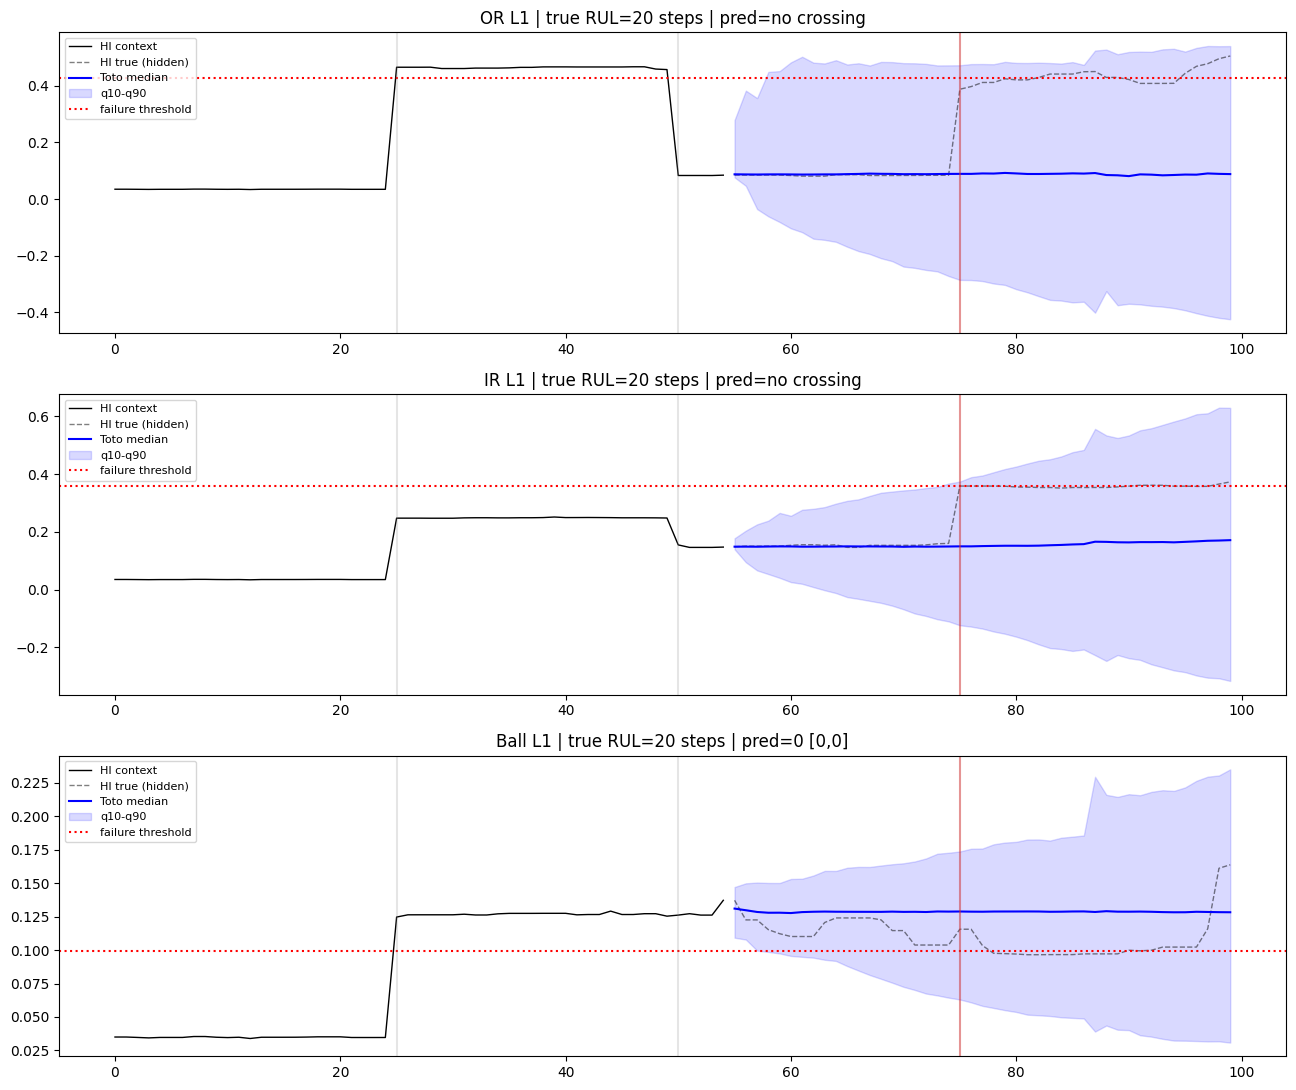


Proxy-RUL results:
  OR: true=20 pred=None abs_err=None q-band=(3, None)
  IR: true=20 pred=None abs_err=None q-band=(19, None)
  Ball: true=20 pred=0 abs_err=20 q-band=(0, 0)

CAVEAT: severity-ordered CWRU segments are a step-function proxy, not real
degradation. Real capability requires run-to-failure data (XJTU-SY, IMS, PRONOSTIA/FEMTO).


In [11]:
def segment_hi(seg):
    filt = bandpass_sos(seg['signal'].astype(np.float64), 1000, min(5400,0.45*seg['fs']), seg['fs'])
    return np.log1p(np.sqrt(np.mean(filt**2)))

def build_trajectory(fault, load, per_sev=25):
    """Pseudo run-to-failure HI series: Normal -> sev7 -> sev14 -> sev21."""
    blocks = []
    for sev, f in [(0,'Normal'),(7,fault),(14,fault),(21,fault)]:
        ss = [s for s in cwru_segs if s['fault']==f and s['sev']==sev and s['load']==load]
        ss = sorted(ss, key=lambda s: s['seg_idx'])[:per_sev]
        blocks.append(np.array([segment_hi(s) for s in ss]))
    hi = np.concatenate(blocks)
    # rolling median smoothing
    k = 5; pad = np.pad(hi, (k//2,k//2), mode='edge')
    hi_s = np.array([np.median(pad[i:i+k]) for i in range(len(hi))])
    bounds = np.cumsum([len(b) for b in blocks])
    return hi_s, bounds   # bounds[2] = start of sev-21 block ("failure onset")

@torch.no_grad()
def toto_forecast(series, horizon):
    """Toto quantile forecast. Context is LEFT-padded to a multiple of patch_size
    (padded region masked out) because model.forecast() requires it."""
    s = np.asarray(series, dtype=np.float32)
    pad = (-len(s)) % PATCH
    x = torch.as_tensor(s, device=device)[None,None,:]
    m = torch.ones_like(x, dtype=torch.bool)
    if pad:
        x = torch.cat([torch.zeros(1,1,pad, device=device), x], dim=-1)
        m = torch.cat([torch.zeros(1,1,pad, dtype=torch.bool, device=device), m], dim=-1)
    ids = torch.zeros(1,1, dtype=torch.long, device=device)
    q = model.forecast({"target":x, "target_mask":m, "series_ids":ids}, horizon=horizon)
    return q[:,0,0,:horizon].float().cpu().numpy()     # (9, horizon)

fig, axes = plt.subplots(3, 1, figsize=(13,11), sharex=False)
results_rul = []
CUT_FRAC = 0.55

for ax, fault in zip(axes, ['OR','IR','Ball']):
    hi, bounds = build_trajectory(fault, load=1)
    n = len(hi); cut = int(CUT_FRAC*n); horizon = n - cut
    fail_thresh = np.median(hi[bounds[2]:])            # sev-21 level
    onset_true  = bounds[2]                            # true "failure onset" index
    rul_true    = onset_true - cut

    q = toto_forecast(hi[:cut], horizon)
    med, q10, q90 = q[4], q[0], q[8]
    def crossing(arr):
        idx = np.where(arr >= fail_thresh)[0]
        return int(idx[0]) if len(idx) else None
    rul_med, rul_lo, rul_hi = crossing(med), crossing(q90), crossing(q10)

    t = np.arange(n); tf = np.arange(cut, n)
    ax.plot(t[:cut], hi[:cut], 'k-', lw=1, label='HI context')
    ax.plot(t[cut:], hi[cut:], 'k--', lw=1, alpha=0.5, label='HI true (hidden)')
    ax.plot(tf, med, 'b-', label='Toto median')
    ax.fill_between(tf, q10, q90, color='b', alpha=0.15, label='q10-q90')
    ax.axhline(fail_thresh, color='r', ls=':', label='failure threshold')
    ax.axvline(onset_true, color='r', alpha=0.4)
    for b in bounds[:-1]: ax.axvline(b, color='gray', alpha=0.2)
    msg = (f"{fault} L1 | true RUL={rul_true} steps | "
           f"pred={rul_med if rul_med is not None else 'no crossing'}"
           + (f" [{rul_lo},{rul_hi}]" if rul_lo is not None and rul_hi is not None else ""))
    ax.set_title(msg); ax.legend(loc='upper left', fontsize=8)
    results_rul.append({'fault':fault,'rul_true':rul_true,'rul_pred':rul_med,
                        'band':(rul_lo,rul_hi)})
plt.tight_layout(); plt.show()

print("\nProxy-RUL results:")
for r in results_rul:
    err = (abs(r['rul_pred']-r['rul_true']) if r['rul_pred'] is not None else None)
    print(f"  {r['fault']}: true={r['rul_true']} pred={r['rul_pred']} "
          f"abs_err={err} q-band={r['band']}")
print("\nCAVEAT: severity-ordered CWRU segments are a step-function proxy, not real")
print("degradation. Real capability requires run-to-failure data (XJTU-SY, IMS, PRONOSTIA/FEMTO).")

## 9. Cross-Dataset: CWRU-trained classifier → Paderborn

ENV representation is order-normalized, so it *should* transfer better than RAW.
Only the 3 shared classes (Normal / IR / OR) are testable.

In [12]:
if PADERBORN_AVAILABLE:
    pd_sub = subsample(pad_segs, 15)
    # ENV rep for Paderborn uses PAD orders implicitly via the same fixed order grid
    EMB_ENV_PAD = compute_embeddings(pd_sub, envelope_order_spectrum, desc='Toto ENV emb (PAD)')
    y_pad = np.array([s['fault'] for s in pd_sub])
    yp = clf_env.predict(sc_env.transform(EMB_ENV_PAD))
    keep = np.isin(y_pad, ['Normal','IR','OR'])
    acc = accuracy_score(y_pad[keep], yp[keep])
    print(f"CWRU->Paderborn (ENV embeddings, zero adaptation): acc={acc:.3f}")
    print(classification_report(y_pad[keep], yp[keep], zero_division=0))
    print("NOTE: bearing geometries differ (CWRU BPFO=3.585x vs PAD BPFO=3.048x) —")
    print("fault peaks sit at DIFFERENT order-grid positions. A geometry-aware alignment")
    print("(remap grid by orders ratio) is the obvious modification if transfer is weak.")
else:
    print("Paderborn unavailable — skipped.")

Toto ENV emb (PAD): 100%|██████████| 22/22 [00:04<00:00,  4.50it/s]


CWRU->Paderborn (ENV embeddings, zero adaptation): acc=0.295
              precision    recall  f1-score   support

        Ball       0.00      0.00      0.00         0
          IR       0.31      0.20      0.24       110
      Normal       0.37      0.14      0.21       132
          OR       0.29      0.57      0.38       110

    accuracy                           0.30       352
   macro avg       0.24      0.23      0.21       352
weighted avg       0.32      0.30      0.27       352

NOTE: bearing geometries differ (CWRU BPFO=3.585x vs PAD BPFO=3.048x) —
fault peaks sit at DIFFERENT order-grid positions. A geometry-aware alignment
(remap grid by orders ratio) is the obvious modification if transfer is weak.


## 10. Capability Summary

In [13]:
print("="*72)
print("TOTO 2.0-313M CAPABILITY PROBE — SUMMARY")
print("="*72)
print(f"""
NATIVE capabilities (no modification):
  - Zero-shot probabilistic forecasting (9 quantiles) ......... USED for RUL
  - Missing-value handling, multivariate series ............... available
  - NO classification / regression / RUL heads ................ everything else is bolted on

Probed with frozen embeddings + linear heads (train loads 0-2, test load 3):
  Fault classification  RAW emb: acc={acc_raw:.3f}  ENV emb: acc={acc_env:.3f}  baseline: acc={acc_stat:.3f}
  (Severity / RPM / RUL numbers printed in their cells above)

Structural limits found BEFORE any modification effort:
  1. Ball_cage (FTF) class: ZERO labeled data in CWRU + Paderborn. Unvalidatable.
  2. RUL on CWRU is proxy-only (severity ordering != degradation).
     -> XJTU-SY / IMS / FEMTO needed for a defensible RUL claim.
  3. RPM: 67-RPM total range, single unseen speed. PLL remains the right tool.
  4. If ENV >> RAW, the value lies in YOUR physics-informed representation,
     not in the foundation model — that is the paper-relevant finding.

Decision guide for modifications:
  - ENV emb >= ~0.90 and >> baseline  -> fine-tune Toto encoder / add task heads is promising
  - ENV emb ~= baseline               -> Toto adds little; keep FHSS/DSSS + your Transformer
  - RUL bands well-calibrated         -> Toto as the forecasting agent in Paper 2's framework
""")

TOTO 2.0-313M CAPABILITY PROBE — SUMMARY

NATIVE capabilities (no modification):
  - Zero-shot probabilistic forecasting (9 quantiles) ......... USED for RUL
  - Missing-value handling, multivariate series ............... available
  - NO classification / regression / RUL heads ................ everything else is bolted on

Probed with frozen embeddings + linear heads (train loads 0-2, test load 3):
  Fault classification  RAW emb: acc=0.993  ENV emb: acc=0.960  baseline: acc=0.947
  (Severity / RPM / RUL numbers printed in their cells above)

Structural limits found BEFORE any modification effort:
  1. Ball_cage (FTF) class: ZERO labeled data in CWRU + Paderborn. Unvalidatable.
  2. RUL on CWRU is proxy-only (severity ordering != degradation).
     -> XJTU-SY / IMS / FEMTO needed for a defensible RUL claim.
  3. RPM: 67-RPM total range, single unseen speed. PLL remains the right tool.
  4. If ENV >> RAW, the value lies in YOUR physics-informed representation,
     not in the foundatio